In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#### DATASET UNDERSTANDING

In [2]:
titanic=sns.load_dataset('titanic')

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [5]:
titanic.shape

(891, 15)

In [6]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [7]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
titanic.groupby("survived")["sex"].value_counts()

survived  sex   
0         male      468
          female     81
1         female    233
          male      109
Name: count, dtype: int64

In [9]:
titanic.corr(numeric_only=True).round(2)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.00,-0.34,-0.08,-0.04,0.08,0.26,-0.56,-0.20
pclass,-0.34,1.00,-0.37,0.08,0.02,-0.55,0.09,0.14
age,-0.08,-0.37,1.00,-0.31,-0.19,0.10,0.28,0.20
sibsp,-0.04,0.08,-0.31,1.00,0.41,0.16,-0.25,-0.58
parch,0.08,0.02,-0.19,0.41,1.00,0.22,-0.35,-0.58
fare,0.26,-0.55,0.10,0.16,0.22,1.00,-0.18,-0.27
adult_male,-0.56,0.09,0.28,-0.25,-0.35,-0.18,1.00,0.40
alone,-0.20,0.14,0.20,-0.58,-0.58,-0.27,0.40,1.00


In [10]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
numeric_cols=titanic.select_dtypes(include=['number']).columns.tolist()
categorical_cols= titanic.select_dtypes(include=['object', 'category']).columns. tolist()

In [12]:
print(numeric_cols)

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


In [13]:
print(categorical_cols)

['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


#### DATA QUALITY

In [14]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [15]:
null_percent=(titanic.isnull().sum()/891)*100
null_percent

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [16]:
#efficient way
null_percent=titanic.isnull().mean()*100
null_percent

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [17]:
# to check for duplicate values in each columns
titanic.nunique()

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [18]:
titanic.duplicated().sum()

np.int64(107)

In [19]:
zero_variance_cols = [col for col in titanic.columns if titanic[col].nunique()==1]

zero_variance_cols

[]

In [20]:
high_misssing_cols= [col for col in titanic.columns[titanic.isnull().mean()>0.6]]
high_misssing_cols

['deck']

In [21]:
high_cardinality__cols = [col for col in titanic.select_dtypes(include=['object', 'category']).columns if titanic[col].nunique()/len(titanic)>0.90]
high_cardinality__cols

[]

In [22]:
titanic['embark_town'].value_counts(dropna=False)

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

In [23]:
titanic[['age', 'fare']].describe()

,age,fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [24]:
titanic[titanic['fare'] == 0]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
179,0,3,male,36.0,0,0,0.0,S,Third,man,True,NaN,Southampton,no,True
263,0,1,male,40.0,0,0,0.0,S,First,man,True,B,Southampton,no,True
271,1,3,male,25.0,0,0,0.0,S,Third,man,True,NaN,Southampton,yes,True
277,0,2,male,NaN,0,0,0.0,S,Second,man,True,NaN,Southampton,no,True
302,0,3,male,19.0,0,0,0.0,S,Third,man,True,NaN,Southampton,no,True
413,0,2,male,NaN,0,0,0.0,S,Second,man,True,NaN,Southampton,no,True
466,0,2,male,NaN,0,0,0.0,S,Second,man,True,NaN,Southampton,no,True
481,0,2,male,NaN,0,0,0.0,S,Second,man,True,NaN,Southampton,no,True
597,0,3,male,49.0,0,0,0.0,S,Third,man,True,NaN,Southampton,no,True
633,0,1,male,NaN,0,0,0.0,S,First,man,True,NaN,Southampton,no,True


#### UNIVARIATE ANALYSIS

In [25]:
titanic['age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

(array([30., 14., 10., 14.,  3., 29., 39., 65., 73., 42., 65., 62., 33.,
        47., 38., 21., 28., 21., 16., 14., 15.,  7.,  9.,  8.,  4.,  0.,
         5.,  1.,  0.,  1.]),
 array([ 0.42      ,  3.07266667,  5.72533333,  8.378     , 11.03066667,
        13.68333333, 16.336     , 18.98866667, 21.64133333, 24.294     ,
        26.94666667, 29.59933333, 32.252     , 34.90466667, 37.55733333,
        40.21      , 42.86266667, 45.51533333, 48.168     , 50.82066667,
        53.47333333, 56.126     , 58.77866667, 61.43133333, 64.084     ,
        66.73666667, 69.38933333, 72.042     , 74.69466667, 77.34733333,
        80.        ]),
 <BarContainer object of 30 artists>)

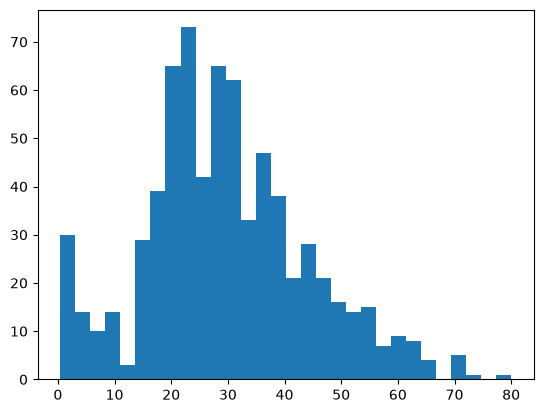

In [26]:
plt.hist(titanic['age'], bins=30)

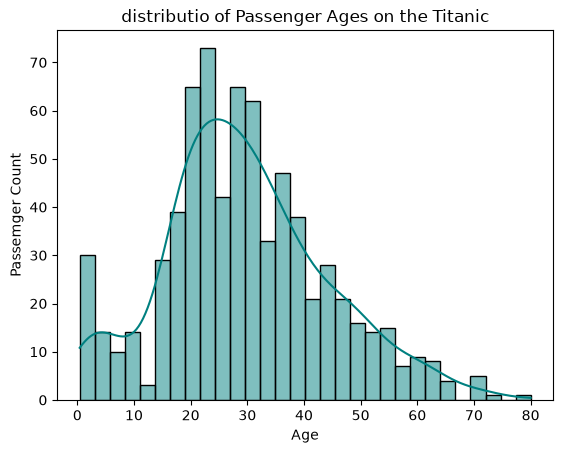

In [27]:
sns.histplot(data=titanic, x='age', kde=True, bins=30, color='teal')
plt.title("distributio of Passenger Ages on the Titanic")
plt.xlabel('Age')
plt.ylabel('Passemger Count')
plt.show()

In [28]:
titanic['fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

<Axes: xlabel='fare', ylabel='Count'>

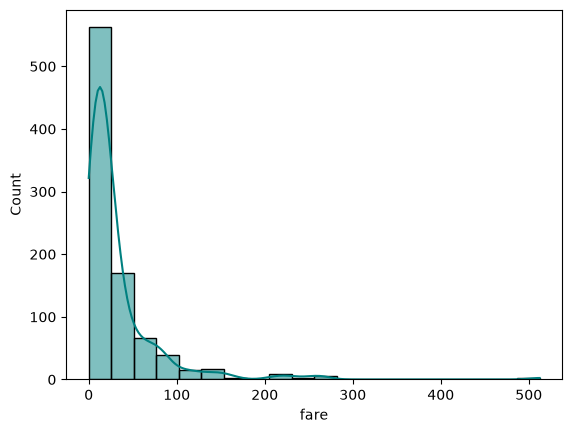

In [29]:
sns.histplot(data=titanic, x='fare', kde=True, bins=20, color='teal')

In [30]:
titanic.groupby('sex')['sex'].count()

sex
female    314
male      577
Name: sex, dtype: int64

In [31]:
titanic.groupby('pclass')['pclass'].count()

pclass
1    216
2    184
3    491
Name: pclass, dtype: int64

In [32]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [33]:
titanic.groupby('survived')['survived'].count()

survived
0    549
1    342
Name: survived, dtype: int64

In [34]:
counts=titanic['embark_town'].value_counts(dropna=False)
percentages= titanic['embark_town'].value_counts(normalize=True, dropna=False)*100

distribution=pd.DataFrame({'Passenger count': counts, 'Percentage (%)': percentages})
distribution

,Passenger count,Percentage (%)
embark_town,,
Southampton,644,72.278339
Cherbourg,168,18.855219
Queenstown,77,8.641975
NaN,2,0.224467


<Axes: xlabel='embarked', ylabel='survived'>

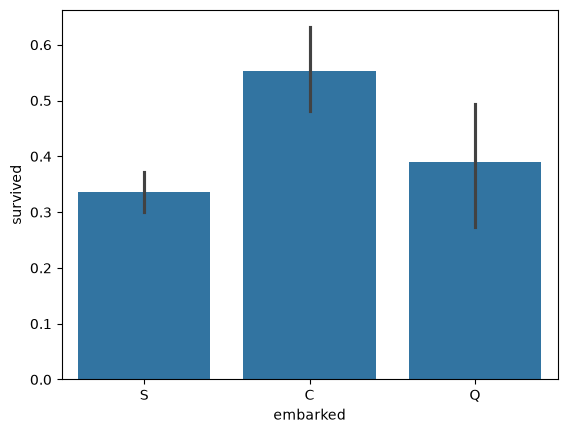

In [35]:
sns.barplot(x='embarked',y='survived', data=titanic)

In [36]:
# to find most common passenger class
titanic['pclass'].mode()[0]

np.int64(3)

In [37]:
titanic['age'].mode()[0]

np.float64(24.0)

In [38]:
# most common age group in titanic
most_common_age_grp=pd.cut(titanic['age'], bins=8).value_counts().idxmax()
most_common_age_grp

Interval(20.315, 30.263, closed='right')

In [39]:
not_survived=(1-titanic['survived'].mean())*100
not_survived

np.float64(61.61616161616161)

#### SURVIVAL ANALYSIS

In [40]:
survived_ppl=titanic['survived'].mean()*100
survived_ppl

np.float64(38.38383838383838)

In [41]:
titanic.groupby(['sex', 'survived'])['survived'].count()

sex     survived
female  0            81
        1           233
male    0           468
        1           109
Name: survived, dtype: int64

In [42]:
titanic.groupby(['pclass'])['survived'].mean()*100

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64

In [43]:
age_bins=[0, 12, 18, 35, 60, 100]
age_labels= ['child (0-12)', 'Teen (13-18)', 'Young Adult(19-35)', 'Adult (36-60)', 'Senior (60+)']
titanic['age_group']=pd.cut(titanic['age'], bins=age_bins, labels=age_labels)
titanic.groupby('age_group')['survived'].mean()*100

C:\Users\neha0\AppData\Local\Temp\ipykernel_32836\1597115967.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('age_group')['survived'].mean()*100


age_group
child (0-12)          57.971014
Teen (13-18)          42.857143
Young Adult(19-35)    38.268156
Adult (36-60)         40.000000
Senior (60+)          22.727273
Name: survived, dtype: float64

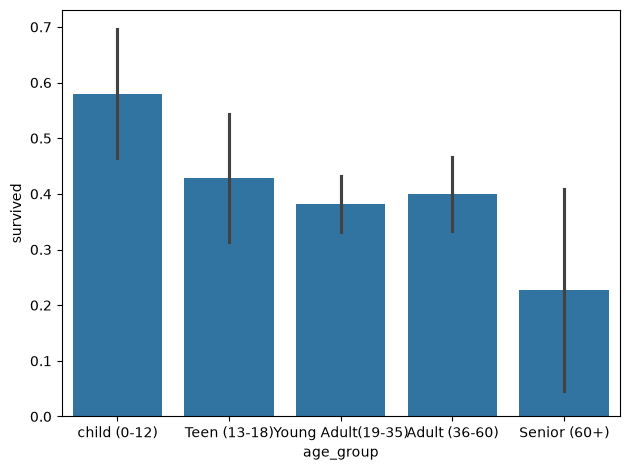

In [44]:
sns.barplot(x='age_group', y='survived', data=titanic)
plt.tight_layout()

In [45]:
(titanic.groupby('pclass')['survived'].mean()*100).idxmax()

np.int64(1)

#### BIVARIATE ANALYSIS

In [46]:
titanic.groupby('sex')['survived'].mean()*100

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

In [47]:
titanic.groupby('sex')['survived'].value_counts()

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

C:\Users\neha0\AppData\Local\Temp\ipykernel_32836\3387024872.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='sex', y='survived', palette='muted')


<Axes: xlabel='sex', ylabel='survived'>

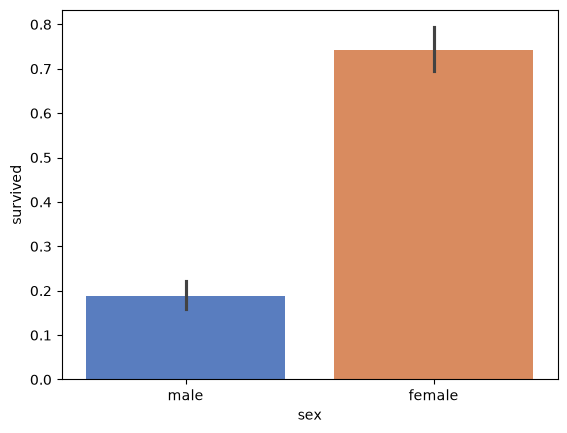

In [48]:
sns.barplot(data=titanic, x='sex', y='survived', palette='muted')

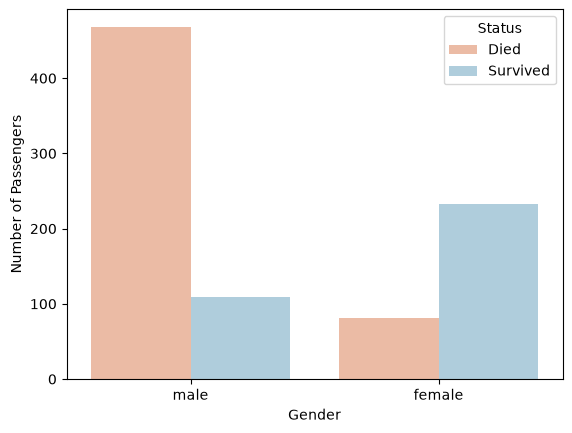

In [49]:
sns.countplot(data=titanic, x='sex', hue='survived', palette='RdBu')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Status', labels=['Died','Survived'])
plt.show()

In [50]:
titanic.groupby('pclass')['survived'].mean()*100

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64

<Axes: xlabel='pclass', ylabel='survived'>

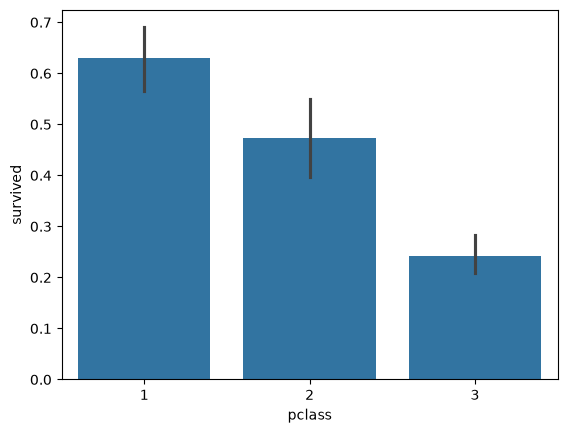

In [51]:
sns.barplot(x='pclass', y='survived', data=titanic)

In [52]:
age_bins=[0, 12, 35, 60, 100]
age_labels=['Child (0- 12)', 'Young Adults (12-35)', 'Adults (35-60)', 'Senior citizens (60+)']

titanic['age_group']=pd.cut(titanic['age'], bins=age_bins, labels=age_labels)
titanic.groupby('age_group')['survived'].mean()*100

C:\Users\neha0\AppData\Local\Temp\ipykernel_32836\795094494.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('age_group')['survived'].mean()*100


age_group
Child (0- 12)            57.971014
Young Adults (12-35)     39.018692
Adults (35-60)           40.000000
Senior citizens (60+)    22.727273
Name: survived, dtype: float64

<Axes: xlabel='age'>

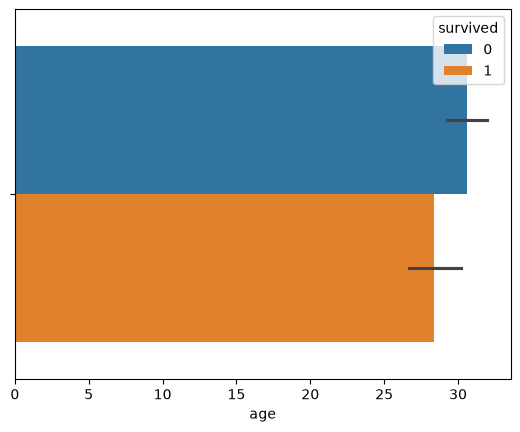

In [53]:
sns.barplot(data=titanic, x='age', hue='survived')

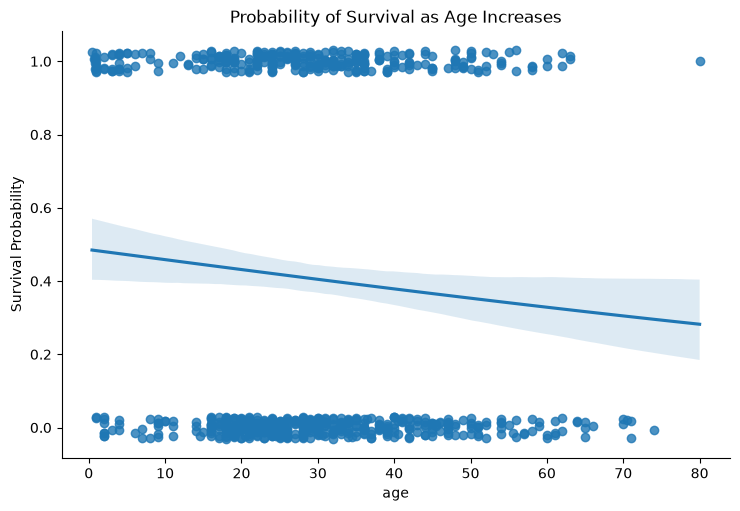

In [54]:
# Plots a logistic trendline showing survival probability by age
sns.lmplot(data=titanic, x='age', y='survived', logistic=True, y_jitter=0.03, aspect=1.5)

plt.title('Probability of Survival as Age Increases')
plt.ylabel('Survival Probability')
plt.show()


In [56]:
titanic.groupby('embarked')['survived'].mean()*100

embarked
C    55.357143
Q    38.961039
S    33.695652
Name: survived, dtype: float64

<Axes: xlabel='embarked', ylabel='survived'>

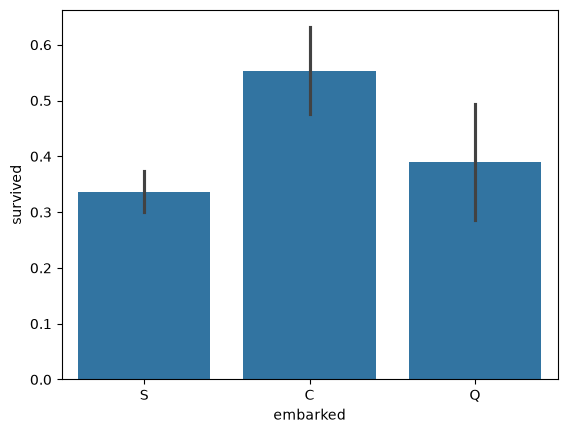

In [58]:
sns.barplot(x='embarked', y='survived', data=titanic)

In [62]:
titanic.groupby('pclass')['fare'].mean()

pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64

In [63]:
titanic.groupby('pclass')['age'].mean()

pclass
1    38.233441
2    29.877630
3    25.140620
Name: age, dtype: float64

In [64]:
titanic.groupby('sibsp')['survived'].agg(['count', 'mean'])

,count,mean
sibsp,,
0,608,0.345395
1,209,0.535885
2,28,0.464286
3,16,0.250000
4,18,0.166667
5,5,0.000000
8,7,0.000000


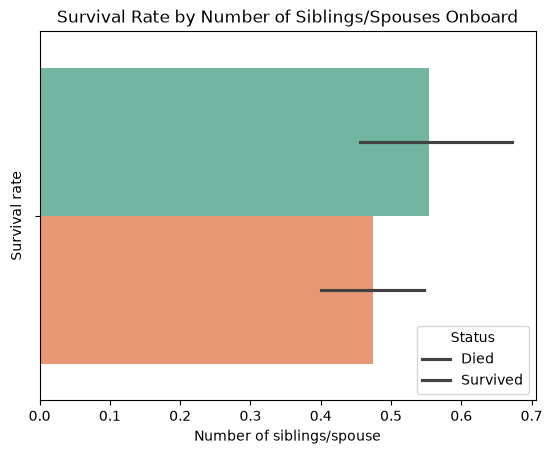

In [72]:
sns.barplot(data=titanic, x='sibsp', hue='survived', palette='Set2')
plt.title("Survival Rate by Number of Siblings/Spouses Onboard")
plt.xlabel('Number of siblings/spouse')
plt.ylabel('Survival rate')
plt.legend(title='Status', labels=['Died', 'Survived'])

In [73]:
titanic.groupby('parch')['survived'].agg(['count', 'mean'])

,count,mean
parch,,
0,678,0.343658
1,118,0.550847
2,80,0.500000
3,5,0.600000
4,4,0.000000
5,5,0.200000
6,1,0.000000


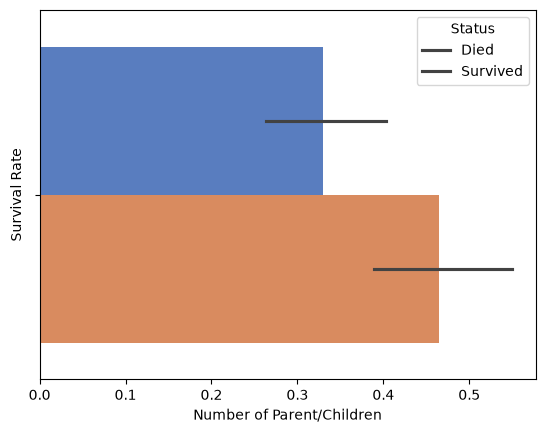

In [74]:
sns.barplot(x='parch', hue='survived', data=titanic, palette='muted')
plt.xlabel('Number of Parent/Children')
plt.ylabel('Survival Rate')
plt.legend(title='Status', labels=['Died', 'Survived'])
